# PCA Compression of SCR Model Output Signals

This notebook tests whether PCA can accurately compress the SCR forward-model output time series.

The training data consists of model output signals

$$
y^{(m)} =
\begin{bmatrix}
y^{(m)}(t_1) &
y^{(m)}(t_2) &
\cdots &
y^{(m)}(t_{N_t})
\end{bmatrix}^T
\in \mathbb{R}^{N_t},
\qquad m = 1,\dots,N_s
$$

where \(N_s = 5000\) is the number of sampled simulations and \(N_t = 11993\) is the number of time points.

PCA represents each signal approximately as

$$
y^{(m)}
\approx
\bar{y}
+
\Phi_r u^{(m)}
$$

where:

- $\bar{y} \in \mathbb{R}^{N_t}$ is the mean signal,
- $\Phi_r \in \mathbb{R}^{N_t \times r}$ contains the first $r$ PCA modes,
- $u^{(m)} \in \mathbb{R}^{r}$ is the vector of PCA coefficients for sample $m$.

Stacking all PCA coefficient vectors gives

$$
U =
\begin{bmatrix}
(u^{(1)})^T \\
(u^{(2)})^T \\
\vdots \\
(u^{(N_s)})^T
\end{bmatrix}
\in \mathbb{R}^{N_s \times r}.
$$

The goal here is only to answer:

$$
\boxed{
\text{How many PCA modes are needed to reconstruct the NOx time series accurately?}
}
$$

## 1. Imports and Paths

Set up repository paths and import standard packages.

In [23]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Current notebook is in ~/AME508/2_PCA
ROOT = Path.cwd().parent

DATASET_DIR = ROOT / "1_DATA"
PCA_DIR = ROOT / "2_PCA"

FULL_DATASET_PATH = DATASET_DIR / "Full_Dataset.npy"
LHS_SAMPLING_PATH = DATASET_DIR / "lhs_sampling.npy"
SCR_TIME_PATH = DATASET_DIR / "scr_time.npy"
DATA_GENERATION_PATH = DATASET_DIR / "dataGeneration.py"

sys.path.append(str(DATASET_DIR))

print("cwd:", Path.cwd())
print("ROOT:", ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("PCA_DIR:", PCA_DIR)

print("\nFiles:")
for name, path in {
    "Full_Dataset.npy": FULL_DATASET_PATH,
    "lhs_sampling.npy": LHS_SAMPLING_PATH,
    "scr_time.npy": SCR_TIME_PATH,
    "dataGeneration.py": DATA_GENERATION_PATH,
}.items():
    print(f"{name:20s} exists = {path.exists()} | {path}")

cwd: /home/ssariedd/AME508/2_PCA
ROOT: /home/ssariedd/AME508
DATASET_DIR: /home/ssariedd/AME508/1_DATA
PCA_DIR: /home/ssariedd/AME508/2_PCA

Files:
Full_Dataset.npy     exists = True | /home/ssariedd/AME508/1_DATA/Full_Dataset.npy
lhs_sampling.npy     exists = True | /home/ssariedd/AME508/1_DATA/lhs_sampling.npy
scr_time.npy         exists = True | /home/ssariedd/AME508/1_DATA/scr_time.npy
dataGeneration.py    exists = True | /home/ssariedd/AME508/1_DATA/dataGeneration.py


## 2. Load Dataset

For PCA compression, we only need the simulated output time series.

Here, `Full_Dataset.npy` contains the SCR model output signals generated from the LHS parameter samples. We treat each row as one model-output signal.

In [13]:
Y = np.load(FULL_DATASET_PATH)
A = np.load(LHS_SAMPLING_PATH)
t = np.load(SCR_TIME_PATH)

print("Y shape:", Y.shape)
print("A shape:", K.shape)
print("t shape:", t.shape)

Y shape: (5000, 11993)
A shape: (5000, 6)
t shape: (11993,)


## 3. Inspect Sample Output Signals

Before applying PCA, inspect several simulated NOx time series to understand the signal scale, peak structure, and variability across samples.

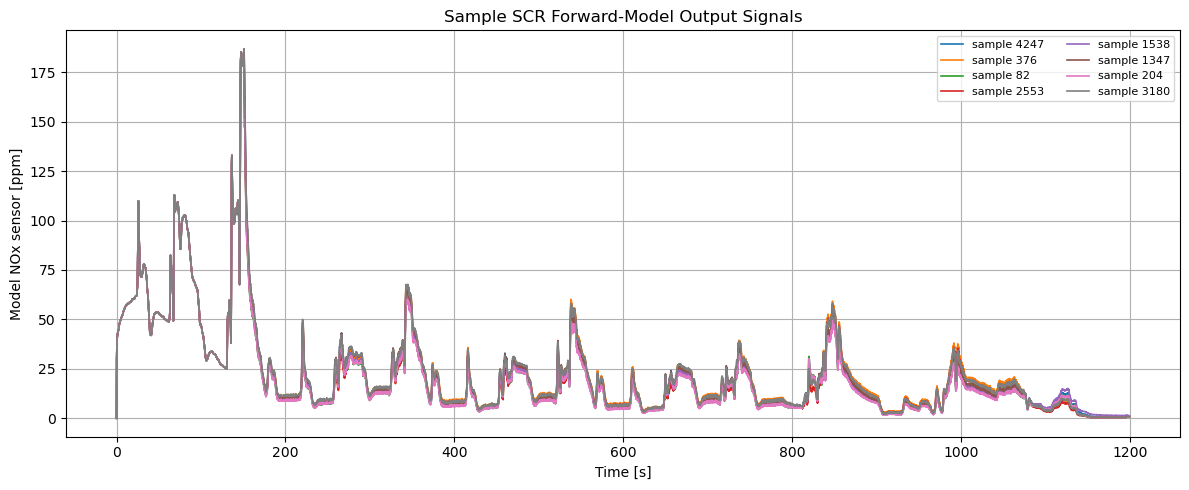

In [4]:
# Step 3: Inspect data

n_samples, n_time = Y.shape

assert len(t) == n_time, "Time vector length does not match Y time dimension."

rng = np.random.default_rng(0)
sample_ids = rng.choice(n_samples, size=8, replace=False)

plt.figure(figsize=(12, 5))

for idx in sample_ids:
    plt.plot(t, Y[idx], linewidth=1.2, label=f"sample {idx}")

plt.xlabel("Time [s]")
plt.ylabel("Model NOx sensor [ppm]")
plt.title("Sample SCR Forward-Model Output Signals")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Fit PCA to Output Signals

We use `sklearn.decomposition.PCA` to compute the PCA basis. Each row of `Y` is one simulated output signal.

In [5]:
# Step 4: Fit PCA

from sklearn.decomposition import PCA

# Keep all possible components initially.
# Since Y has shape (5000, 11993), max number of PCA components is 5000.
pca = PCA()

pca.fit(Y)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("Y shape:", Y.shape)
print("Number of PCA components:", len(explained))

n_print = min(20, len(explained))

print(f"\nCumulative variance first {n_print} modes:")
for i in range(n_print):
    print(f"r = {i+1:2d} | cumulative variance = {cum_explained[i]:.10f}")

Y shape: (5000, 11993)
Number of PCA components: 5000

Cumulative variance first 20 modes:
r =  1 | cumulative variance = 0.7308590970
r =  2 | cumulative variance = 0.9687676891
r =  3 | cumulative variance = 0.9900121252
r =  4 | cumulative variance = 0.9955458747
r =  5 | cumulative variance = 0.9985530869
r =  6 | cumulative variance = 0.9995255546
r =  7 | cumulative variance = 0.9997654995
r =  8 | cumulative variance = 0.9999071203
r =  9 | cumulative variance = 0.9999598754
r = 10 | cumulative variance = 0.9999739579
r = 11 | cumulative variance = 0.9999863977
r = 12 | cumulative variance = 0.9999939347
r = 13 | cumulative variance = 0.9999976588
r = 14 | cumulative variance = 0.9999982087
r = 15 | cumulative variance = 0.9999986200
r = 16 | cumulative variance = 0.9999988678
r = 17 | cumulative variance = 0.9999989514
r = 18 | cumulative variance = 0.9999990274
r = 19 | cumulative variance = 0.9999990991
r = 20 | cumulative variance = 0.9999991517


## 5. PCA Reconstruction Check

Here we choose a PCA rank \(r\), randomly select several signals, and compare original vs reconstructed signals in a compact grid.

In [6]:
# Candidate PCA ranks to test
r_list = [1, 2, 3, 5, 10, 20]

def reconstruct_with_rank(pca, Y, r):
    """
    Reconstruct Y using the first r PCA modes.
    """
    coeffs = pca.transform(Y)[:, :r]
    Y_rec = coeffs @ pca.components_[:r, :] + pca.mean_
    return Y_rec

In [7]:
for r in r_list:
    Y_rec = reconstruct_with_rank(pca, Y, r)

    rmse = np.sqrt(np.mean((Y_rec - Y)**2))
    rel_rmse = rmse / np.sqrt(np.mean(Y**2))
    max_abs_err = np.max(np.abs(Y_rec - Y))

    print(
        f"r = {r:3d} | "
        f"RMSE = {rmse:.4f} ppm | "
        f"rel RMSE = {rel_rmse:.4e} | "
        f"max abs err = {max_abs_err:.4f} ppm"
    )

r =   1 | RMSE = 0.8717 ppm | rel RMSE = 2.6696e-02 | max abs err = 15.4270 ppm
r =   2 | RMSE = 0.2969 ppm | rel RMSE = 9.0942e-03 | max abs err = 6.5379 ppm
r =   3 | RMSE = 0.1679 ppm | rel RMSE = 5.1428e-03 | max abs err = 5.4891 ppm
r =   5 | RMSE = 0.0639 ppm | rel RMSE = 1.9574e-03 | max abs err = 2.1538 ppm
r =  10 | RMSE = 0.0086 ppm | rel RMSE = 2.6260e-04 | max abs err = 0.9565 ppm
r =  20 | RMSE = 0.0015 ppm | rel RMSE = 4.7395e-05 | max abs err = 0.9584 ppm


In [8]:
def plot_pca_reconstruction_rows(
    pca,
    Y,
    t,
    r=10,
    n_show=3,
    seed=0,
):
    """
    Plot n_show randomly selected signals.
    Each signal is plotted on its own full-width row.
    """
    rng = np.random.default_rng(seed)
    sample_ids = rng.choice(Y.shape[0], size=n_show, replace=False)

    Y_rec = reconstruct_with_rank(pca, Y, r)

    fig, axes = plt.subplots(
        nrows=n_show,
        ncols=1,
        figsize=(12, 2.8 * n_show),
        sharex=True,
        sharey=True,
    )

    if n_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_ids):
        ax.plot(t, Y[idx], linewidth=1.2, label="Original")
        ax.plot(t, Y_rec[idx], "--", linewidth=1.2, label=f"PCA r={r}")

        rmse_i = np.sqrt(np.mean((Y_rec[idx] - Y[idx])**2))
        ax.set_title(f"sample {idx} | RMSE = {rmse_i:.4f}", fontsize=10)
        ax.grid(True)

    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("Time [s]")
    fig.supylabel("NOx sensor [ppm]")
    fig.suptitle(f"PCA Reconstruction, r={r}", fontsize=13)

    plt.tight_layout()
    plt.show()

    return sample_ids

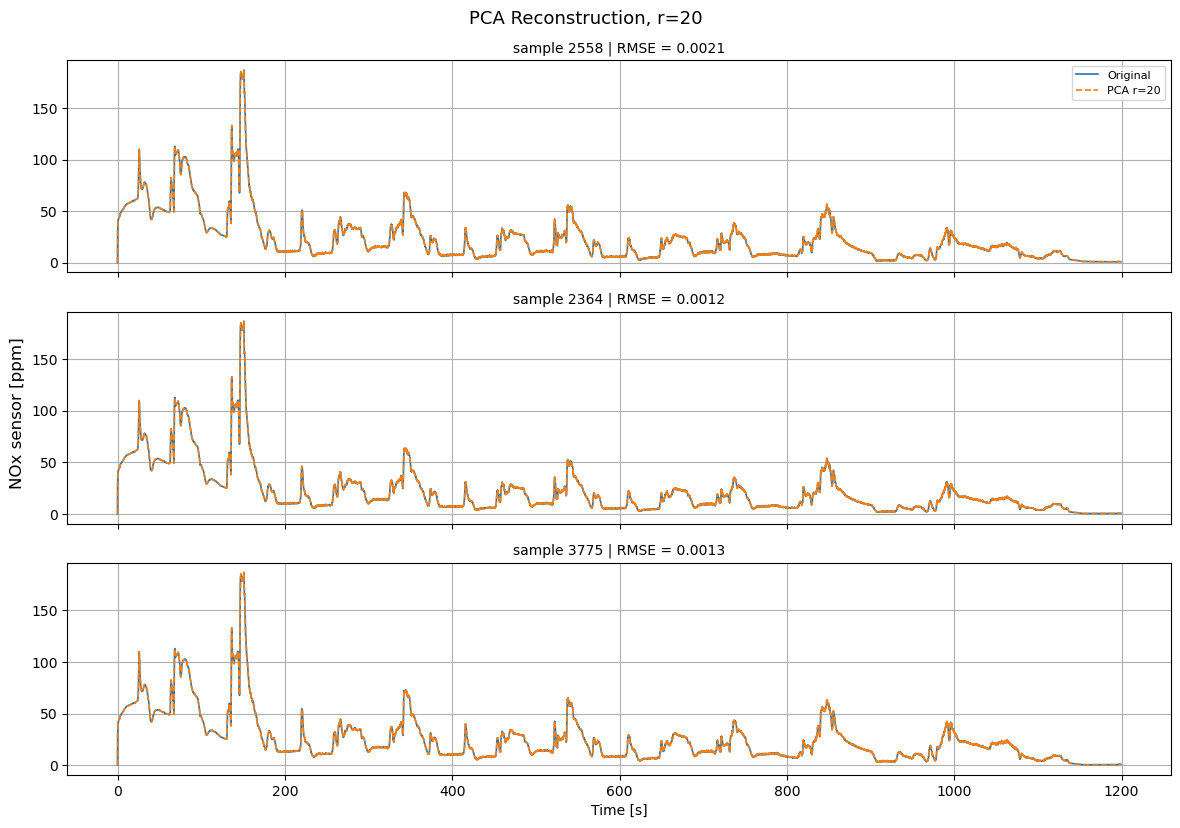

In [9]:
sample_ids = plot_pca_reconstruction_rows(
    pca=pca,
    Y=Y,
    t=t,
    r=20,
    n_show=3,
    seed=1,
)

## 6. Visualize PCA Modes

Plot the first \(r=20\) PCA modes to inspect the dominant temporal patterns learned from the forward-model output signals.

In [10]:
def plot_pca_mean_and_modes(
    pca,
    t,
    n_modes=20,
    nrows=5,
    ncols=4,
):
    """
    Plot the PCA mean signal as one wide top panel,
    followed by the first n_modes PCA modes in a grid.
    """
    assert nrows * ncols >= n_modes, "Need nrows*ncols >= n_modes"

    fig = plt.figure(figsize=(3.8 * ncols, 2.3 * (nrows + 1)))

    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        height_ratios=[1.2] + [1.0] * nrows,
    )

    # Top wide mean-signal panel
    ax_mean = fig.add_subplot(gs[0, :])
    ax_mean.plot(t, pca.mean_, linewidth=1.5)
    ax_mean.set_title("PCA Mean Signal", fontsize=12)
    ax_mean.set_ylabel("NOx [ppm]")
    ax_mean.grid(True)

    # PCA modes grid
    axes = []
    for row in range(nrows):
        for col in range(ncols):
            axes.append(fig.add_subplot(gs[row + 1, col]))

    for i in range(n_modes):
        ax = axes[i]
        ax.plot(t, pca.components_[i], linewidth=1.1)
        ax.set_title(f"Mode {i+1}", fontsize=9)
        ax.grid(True)

    for ax in axes[n_modes:]:
        ax.axis("off")

    fig.suptitle(f"PCA Mean Signal and First {n_modes} Modes", fontsize=14)
    fig.supxlabel("Time [s]")
    fig.supylabel("Amplitude")
    plt.tight_layout()
    plt.show()

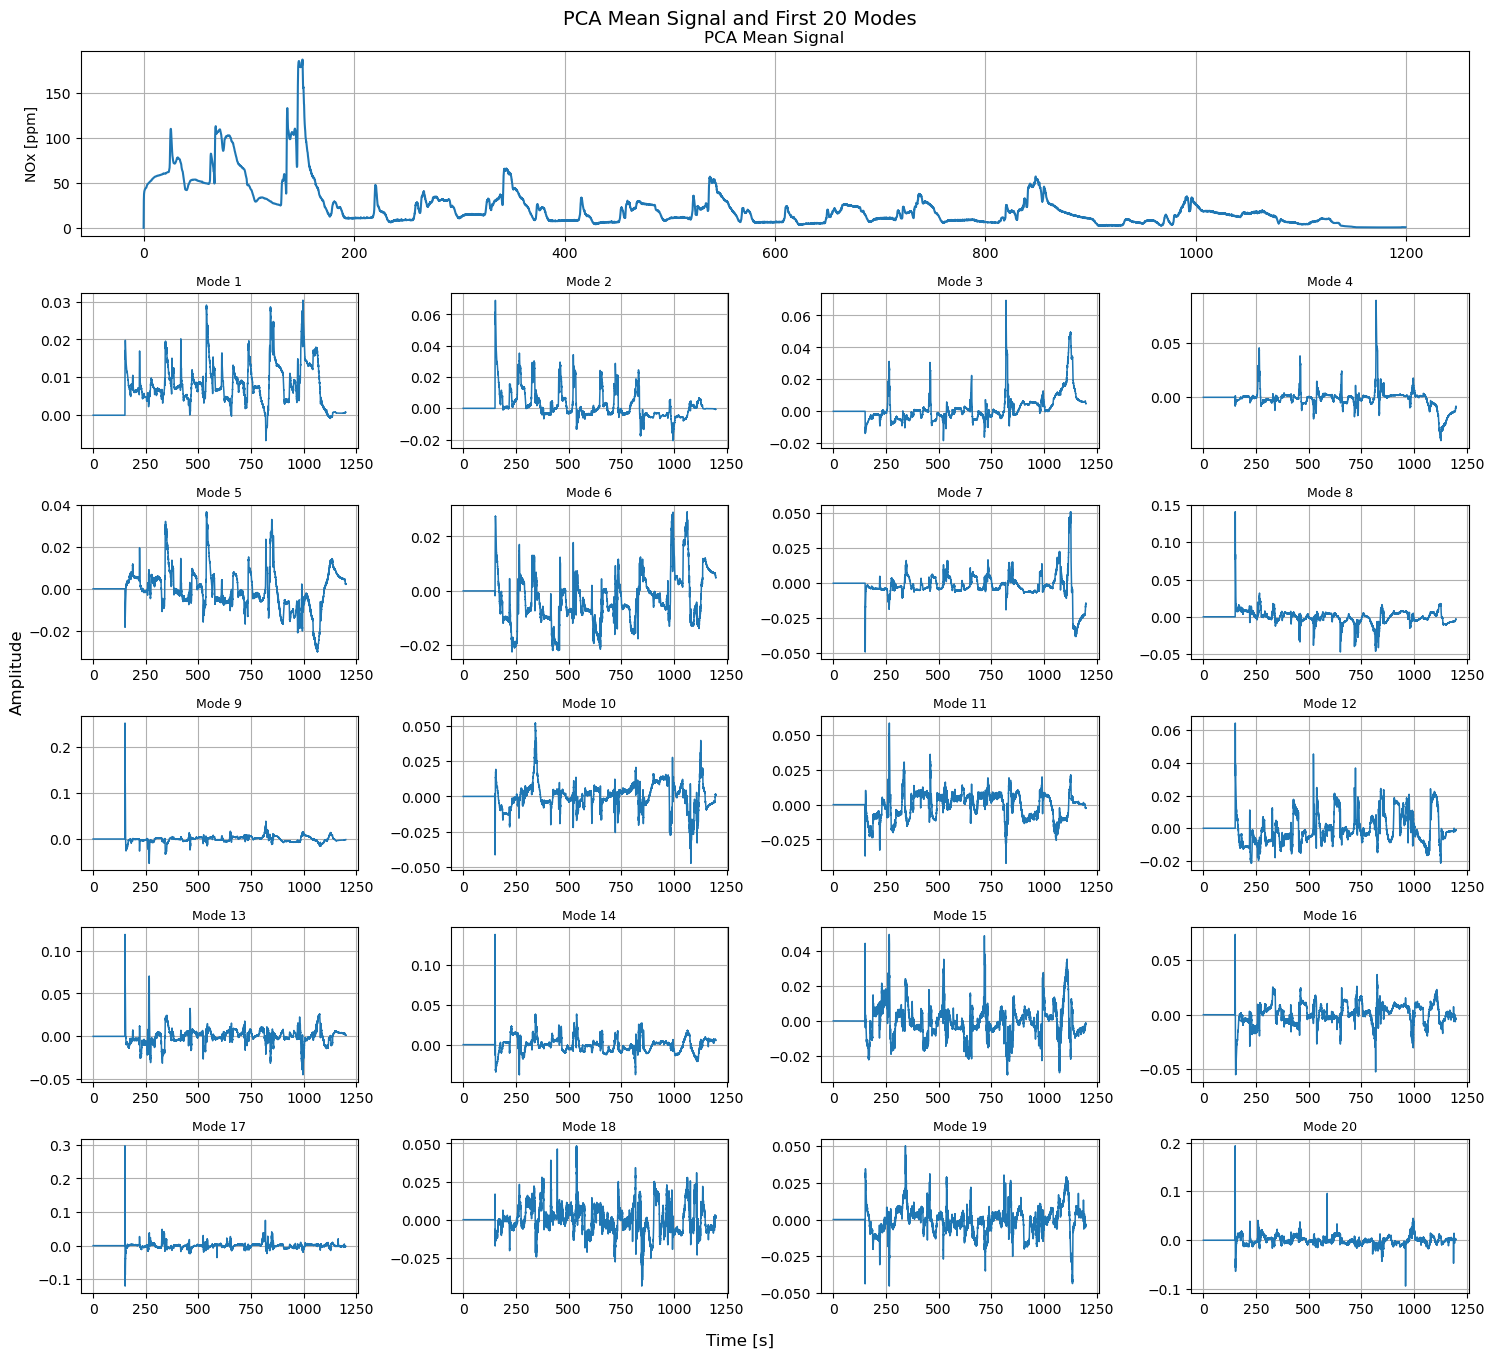

In [11]:
plot_pca_mean_and_modes(
    pca=pca,
    t=t,
    n_modes=20,
    nrows=5,
    ncols=4,
)

## 7. Save PCA Compression Data

We choose $r=20$ PCA modes.

The full dataset matrix is

$$
Y =
\begin{bmatrix}
- & y^{(1)} & - \\
- & y^{(2)} & - \\
  & \vdots  &   \\
- & y^{(N_s)} & -
\end{bmatrix}
\in \mathbb{R}^{N_s \times N_t}.
$$

Each row of $Y$ is one full SCR output time signal.

The compressed PCA representation is

$$
Y \approx \mathbf{1}\bar{y}^T + U\Phi.
$$

Here, $U$ is the PCA coefficient matrix:

$$
U =
\begin{bmatrix}
- & u^{(1)} & - \\
- & u^{(2)} & - \\
  & \vdots  &   \\
- & u^{(N_s)} & -
\end{bmatrix}
\in \mathbb{R}^{N_s \times r}.
$$

Each row $u^{(m)} \in \mathbb{R}^{r}$ contains the PCA coefficients for simulation $m$.

The matrix $\Phi$ contains the PCA modes:

$$
\Phi =
\begin{bmatrix}
- & \phi_1^T & - \\
- & \phi_2^T & - \\
  & \vdots   &   \\
- & \phi_r^T & -
\end{bmatrix}
\in \mathbb{R}^{r \times N_t}.
$$

Each row $\phi_i^T \in \mathbb{R}^{N_t}$ is one PCA mode over time.

Therefore,

$$
U\Phi \in \mathbb{R}^{N_s \times N_t}
$$

reconstructs the centered output signals. The term

$$
\mathbf{1}\bar{y}^T \in \mathbb{R}^{N_s \times N_t}
$$

adds back the mean signal.

We save $U$, $\Phi$, and $\bar{y}$ so that later notebooks can train a surrogate model from kinetic parameters to PCA coefficients.

In [14]:
# Step 7: Save PCA compression data

# Final PCA rank
R_PCA = 20

# PCA coefficients for all output signals
U = pca.transform(Y)[:, :R_PCA]

# PCA modes/components
Phi = pca.components_[:R_PCA, :]

# PCA mean signal
Y_mean = pca.mean_

# Reconstruction using r=20
Y_rec = U @ Phi + Y_mean

# Reconstruction error
rmse = np.sqrt(np.mean((Y_rec - Y)**2))
rel_rmse = rmse / np.sqrt(np.mean(Y**2))
max_abs_err = np.max(np.abs(Y_rec - Y))

print("R_PCA:", R_PCA)
print("U shape:", U.shape)
print("Phi shape:", Phi.shape)
print("Y_mean shape:", Y_mean.shape)
print("Y_rec shape:", Y_rec.shape)
print("RMSE:", rmse)
print("Relative RMSE:", rel_rmse)
print("Max absolute error:", max_abs_err)

R_PCA: 20
U shape: (5000, 20)
Phi shape: (20, 11993)
Y_mean shape: (11993,)
Y_rec shape: (5000, 11993)
RMSE: 0.0015475089058903158
Relative RMSE: 4.7395475564552306e-05
Max absolute error: 0.9584368679119137


In [22]:
PCA_SAVE_PATH = PCA_DIR/"PCA_Dataset_r20.npz"

np.savez(
    PCA_SAVE_PATH,
    r=R_PCA,
    t=t,
    Y_mean=Y_mean,
    Phi=Phi,
    U=U,
    Y_rec=Y_rec,
    explained=explained,
    cum_explained=cum_explained,
    full_dataset_path=str(FULL_DATASET_PATH.relative_to(ROOT)),
    lhs_sampling_path=str(LHS_SAMPLING_PATH.relative_to(ROOT)),
)

print("Saved PCA data to:")
print(PCA_SAVE_PATH)
print("Relative to ROOT:", PCA_SAVE_PATH.relative_to(ROOT))

Saved PCA data to:
/home/ssariedd/AME508/2_PCA/PCA_Dataset_r20.npz
Relative to ROOT: 2_PCA/PCA_Dataset_r20.npz
